In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN
from sklearn.metrics import silhouette_samples, silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
import os
os.chdir("/home/piai/Desktop/git/2. Big Data 분석")

matplotlib.rc("font", family = "NanumSquare")
matplotlib.rc("axes",unicode_minus = False)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## 군집분석

In [2]:
df_raw = pd.read_csv("IRIS.csv")
df_raw.head()

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH,SPECIES
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df_raw_x = df_raw.iloc[:,:-1]
df_raw_y = df_raw.iloc[:,-1]

In [4]:
scaler = StandardScaler()
df_raw_x = scaler.fit_transform(df_raw_x)

df_raw_x[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

In [5]:
z_ward = linkage(df_raw_x, method= "ward", metric= "euclidean")

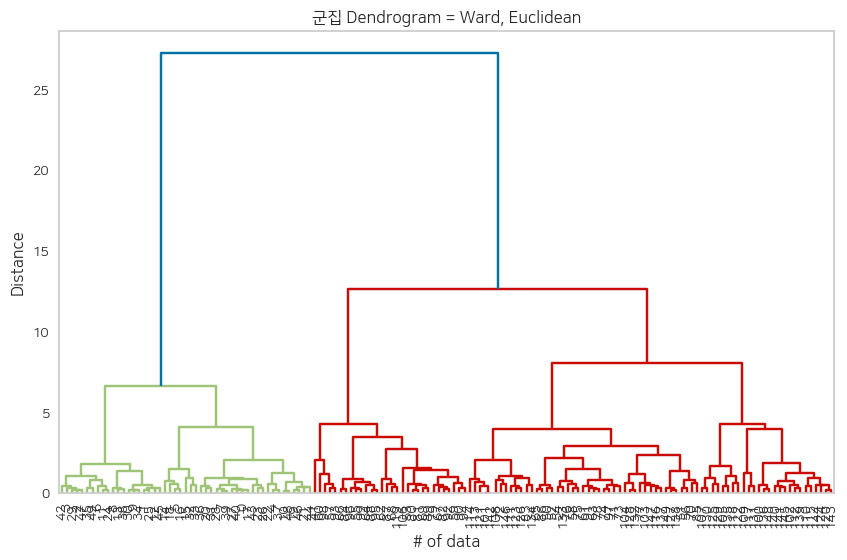

In [6]:
plt.figure(figsize=(10,6))
ax = plt.subplot(111)
dendrogram(z_ward, leaf_font_size=10, orientation="top")
plt.title("군집 Dendrogram = Ward, Euclidean")
plt.xlabel("# of data")
plt.ylabel("Distance")
plt.grid(False)
plt.show()

In [7]:
# 최대 군집 생성 개수
n_iter_cluster = 20
cluster_range = [i+1 for i in range(n_iter_cluster)]
clus_error = []
for v_n_clus in cluster_range:
    clus = KMeans(v_n_clus)
    clus.fit(df_raw_x)
    
    clus_error.append(clus.inertia_)
df_error = pd.DataFrame({"NumberofCluster": cluster_range, "Error": clus_error})
df_error.round(3)

,NumberofCluster,Error
0,1,600.000
1,2,222.362
2,3,139.820
3,4,114.305
4,5,91.047
5,6,80.022
6,7,70.726
7,8,63.372
8,9,54.211
9,10,47.253


Text(0, 0.5, 'Sum of Square')

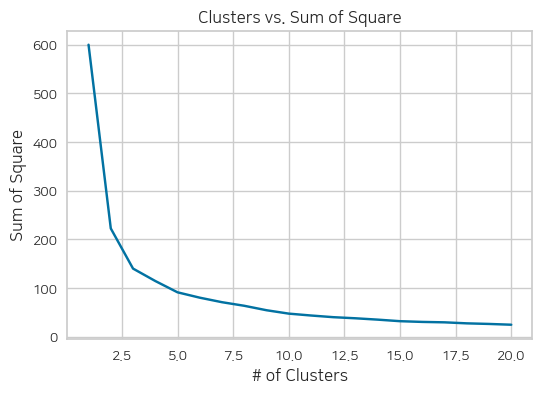

In [8]:
plt.figure(figsize=(6,4))
plt.plot(df_error["NumberofCluster"], df_error["Error"])
plt.title("Clusters vs. Sum of Square")
plt.xlabel("# of Clusters")
plt.ylabel("Sum of Square")

군집 개수를 3개로 설정한다.

In [9]:
cluster_h = fcluster(Z = z_ward, t = 10, criterion= "distance")
df_raw["cluster_H"] = cluster_h
df_raw.head()

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH,SPECIES,cluster_H
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


In [10]:
df_summary_H = df_raw.groupby("cluster_H").agg(["min", "mean", "max"])
level0 = df_summary_H.columns.get_level_values(0)
level1 = df_summary_H.columns.get_level_values(1)
df_summary_H.columns = level0 + "_" + level1
df_summary_H.reset_index(inplace = True)
df_summary_H.round(3)

,cluster_H,SEPAL_LENGTH_min,SEPAL_LENGTH_mean,SEPAL_LENGTH_max,SEPAL_WIDTH_min,SEPAL_WIDTH_mean,SEPAL_WIDTH_max,PETAL_LENGTH_min,PETAL_LENGTH_mean,PETAL_LENGTH_max,PETAL_WIDTH_min,PETAL_WIDTH_mean,PETAL_WIDTH_max
0,1,4.3,5.016,5.8,2.9,3.451,4.4,1.0,1.465,1.9,0.1,0.245,0.6
1,2,4.5,5.530,6.3,2.0,2.567,3.0,1.3,3.930,5.0,0.3,1.207,1.7
2,3,5.6,6.546,7.9,2.5,2.993,3.8,4.0,5.268,6.9,1.2,1.855,2.5


In [11]:
pd.crosstab(df_raw['SPECIES'], df_raw['cluster_H'])

cluster_H,1,2,3
SPECIES,,,
setosa,49,1,0
versicolor,0,27,23
virginica,0,2,48


결과

In [12]:
clus = KMeans(3)
clus.fit(df_raw_x)
cluster_KM = [i+1 for i in clus.labels_]
df_raw["cluster_KM"] = cluster_KM
df_raw.head(10)

,SEPAL_LENGTH,SEPAL_WIDTH,PETAL_LENGTH,PETAL_WIDTH,SPECIES,cluster_H,cluster_KM
0,5.1,3.5,1.4,0.2,setosa,1,2
1,4.9,3.0,1.4,0.2,setosa,1,2
2,4.7,3.2,1.3,0.2,setosa,1,2
3,4.6,3.1,1.5,0.2,setosa,1,2
4,5.0,3.6,1.4,0.2,setosa,1,2
5,5.4,3.9,1.7,0.4,setosa,1,2
6,4.6,3.4,1.4,0.3,setosa,1,2
7,5.0,3.4,1.5,0.2,setosa,1,2
8,4.4,2.9,1.4,0.2,setosa,1,2
9,4.9,3.1,1.5,0.1,setosa,1,2


In [13]:
df_summary_KM = df_raw.drop("cluster_H", axis = 1, inplace=False). \
    groupby("cluster_KM").agg(["min", "mean", "max"])
level0 = df_summary_KM.columns.get_level_values(0)
level1 = df_summary_KM.columns.get_level_values(1)
df_summary_KM.columns = level0 + "_" + level1
df_summary_KM.reset_index(inplace = True)
df_summary_KM.round(3)

,cluster_KM,SEPAL_LENGTH_min,SEPAL_LENGTH_mean,SEPAL_LENGTH_max,SEPAL_WIDTH_min,SEPAL_WIDTH_mean,SEPAL_WIDTH_max,PETAL_LENGTH_min,PETAL_LENGTH_mean,PETAL_LENGTH_max,PETAL_WIDTH_min,PETAL_WIDTH_mean,PETAL_WIDTH_max
0,1,4.9,5.802,6.6,2.0,2.674,3.0,3.0,4.370,5.6,1.0,1.413,2.4
1,2,4.3,5.006,5.8,2.3,3.428,4.4,1.0,1.462,1.9,0.1,0.246,0.6
2,3,5.9,6.781,7.9,2.5,3.096,3.8,4.4,5.511,6.9,1.4,1.972,2.5


Text(0, 0.5, 'Sum of Square')

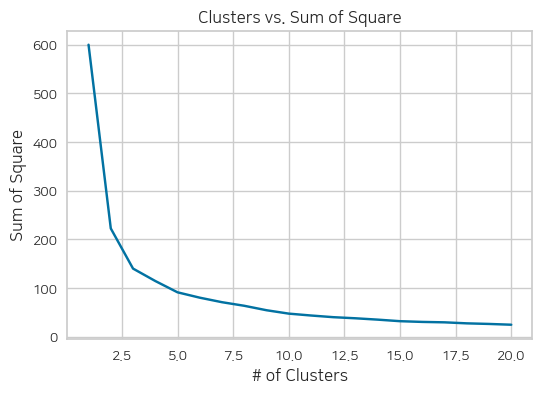

In [14]:
plt.figure(figsize=(6,4))
plt.plot(df_error["NumberofCluster"], df_error["Error"])
plt.title("Clusters vs. Sum of Square")
plt.xlabel("# of Clusters")
plt.ylabel("Sum of Square")

역시 3개로 동일하였다.

In [15]:
df_summary_KM = df_raw.drop("cluster_H", axis = 1, inplace=False). \
    groupby("cluster_KM").agg(["min", "mean", "max"])
level0 = df_summary_KM.columns.get_level_values(0)
level1 = df_summary_KM.columns.get_level_values(1)
df_summary_KM.columns = level0 + "_" + level1
df_summary_KM.reset_index(inplace = True)
df_summary_KM.round(3)

,cluster_KM,SEPAL_LENGTH_min,SEPAL_LENGTH_mean,SEPAL_LENGTH_max,SEPAL_WIDTH_min,SEPAL_WIDTH_mean,SEPAL_WIDTH_max,PETAL_LENGTH_min,PETAL_LENGTH_mean,PETAL_LENGTH_max,PETAL_WIDTH_min,PETAL_WIDTH_mean,PETAL_WIDTH_max
0,1,4.9,5.802,6.6,2.0,2.674,3.0,3.0,4.370,5.6,1.0,1.413,2.4
1,2,4.3,5.006,5.8,2.3,3.428,4.4,1.0,1.462,1.9,0.1,0.246,0.6
2,3,5.9,6.781,7.9,2.5,3.096,3.8,4.4,5.511,6.9,1.4,1.972,2.5


array([[<Axes: title={'center': 'SEPAL_LENGTH'}, xlabel='cluster_H'>,
        <Axes: title={'center': 'SEPAL_WIDTH'}, xlabel='cluster_H'>],
       [<Axes: title={'center': 'PETAL_LENGTH'}, xlabel='cluster_H'>,
        <Axes: title={'center': 'PETAL_WIDTH'}, xlabel='cluster_H'>]],
      dtype=object)

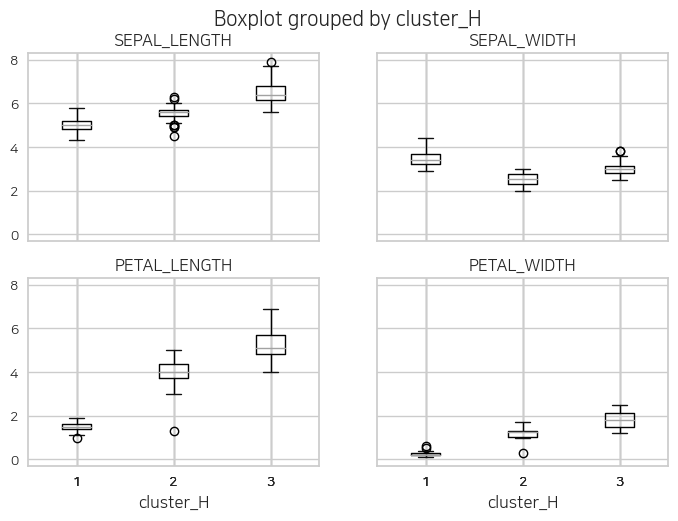

In [16]:
df_raw.boxplot(column = ["SEPAL_LENGTH","SEPAL_WIDTH", "PETAL_LENGTH","PETAL_WIDTH"],
               by = "cluster_H")

엘보우 기법과 덴드로그램 분석결과, 와드분석법과 K-Means 모두 군집 수가 3인 경우에서 데이터 구조를 가장 잘 설명하였다.<br>
군집화분석은 종을 구분하는 데 유의미한 결과를 보였으며, 특히 setosa를 완벽에 가깝게 분리하였다.<br>
나머지 군집도 각각 versicolor와 virginica를 주축으로 했으나, 혼합적으로 분리되었다.<br>
결론적으로, setosa는 명확히 분리되었으나, versicolor와 virginica의 분류 성능 향상을 위한 추가적인 조치가 필요합니다.<br>

## 연관규칙

In [17]:
df_raw = pd.read_csv("구매이력.csv", encoding= 'cp949')
df_raw.head(10)

,ID,PRODUCT
0,CS-102,양주
1,CS-102,양주
2,CS-103,소다
3,CS-103,크래커
4,CS-103,맥주
5,CS-104,크래커
6,CS-104,맥주
7,CS-106,양주
8,CS-106,크래커
9,CS-107,맥주


In [18]:
ID = list(set(df_raw["ID"]))
ID.sort()

list_association = []
for i in ID:
    tmp_list = list(df_raw[df_raw["ID"] == i]["PRODUCT"])
    tmp_list.sort()
    list_association.append(tmp_list)

for row in list_association:
    print(row)

['양주', '양주']
['맥주', '소다', '크래커']
['맥주', '크래커']
['양주', '크래커']
['맥주', '콜라']
['맥주']
['맥주', '소다', '양주', '크래커']
['맥주']
['맥주', '콜라']
['맥주', '콜라']
['맥주', '양주', '콜라']
['맥주', '소다', '양주', '크래커']
['양주']
['맥주', '콜라']
['양주', '콜라']
['맥주', '크래커']
['맥주', '소다', '양주', '크래커']
['맥주', '소다', '양주', '크래커']
['맥주', '소다']
['소다', '양주', '크래커']
['크래커']
['양주', '콜라']
['맥주', '소다', '양주', '콜라', '크래커']
['양주', '콜라']
['맥주', '크래커']
['맥주', '소다', '크래커']
['맥주', '소다', '양주', '크래커']
['맥주']
['맥주', '콜라']
['양주', '콜라', '크래커']
['맥주', '콜라']
['맥주', '크래커']
['맥주']
['맥주', '소다', '양주', '크래커']
['맥주', '소다', '콜라']
['맥주', '콜라', '크래커']
['맥주', '양주']
['맥주', '콜라']
['맥주', '크래커']
['맥주', '소다', '양주', '크래커']
['소다', '양주', '콜라']
['맥주', '크래커']
['소다', '크래커']


In [19]:
enc = TransactionEncoder()
df_raw_enc = enc.fit_transform(X = list_association)
df_asso = pd.DataFrame(df_raw_enc, columns = enc.columns_)
df_asso

,맥주,소다,양주,콜라,크래커
0,False,False,True,False,False
1,True,True,False,False,True
2,True,False,False,False,True
3,False,False,True,False,True
4,True,False,False,True,False
5,True,False,False,False,False
6,True,True,True,False,True
7,True,False,False,False,False
8,True,False,False,True,False
9,True,False,False,True,False


In [20]:
df_freq = apriori(df_asso, min_support = 0.3, use_colnames = True) 
df_freq.round(3) 

,support,itemsets
0,0.744,(맥주)
1,0.349,(소다)
2,0.442,(양주)
3,0.372,(콜라)
4,0.512,(크래커)
5,0.395,"(크래커, 맥주)"


In [21]:
df_asso_rule = association_rules(df_freq, metric="confidence" ,min_threshold = 0.1)
df_asso_rule.round(3) 

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(크래커),(맥주),0.512,0.744,0.395,0.773,1.038,0.015,1.126,0.076
1,(맥주),(크래커),0.744,0.512,0.395,0.531,1.038,0.015,1.042,0.144


In [22]:
df_asso_rule = association_rules(df_freq, metric="lift" ,min_threshold = 1.0)
df_asso_rule.round(3)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(크래커),(맥주),0.512,0.744,0.395,0.773,1.038,0.015,1.126,0.076
1,(맥주),(크래커),0.744,0.512,0.395,0.531,1.038,0.015,1.042,0.144


가장 인기 있는 품목은 전체 거래의 약 74.4%를 차지한 맥주였다.<br>
맥주와 크래커는 전체 거래의 약 39.5%에서 두 품목이 동시에 거래되었다.<br>
고객이 크래커를 구매할 경우 약 77.3%의 확률로 맥주도 함께 구매하는 경향을 보였다.<br>
향상도의 측면에서도 맥주 구매가 크래커 구매 확률을 약간 높이는 연관성이 있었다.<br>
결론적으로 크래커 구매 고객에게 맥주도 추천하여 교차 판매 효과를 극대화해야 합니다.